# Plot: per-patient model term importance

Loads the raw per-patient ANOVA fits from `2.per_patient_variate_importance.ipynb` (`results/per_patient_variate_importance/{organoid,single_cell}_per_patient_anova.parquet`) and plots the distribution of % variance explained per term, pooled across patients.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

TERM_ORDER = [
    "treatment",
    "cell_count",
    "organoid_count",
    "cell_per_organoid_count",
    "residual",
]
anova_dfs = {
    name: pd.read_parquet(results_path / f"{name}_per_patient_anova.parquet")
    for name in ["organoid", "single_cell"]
}

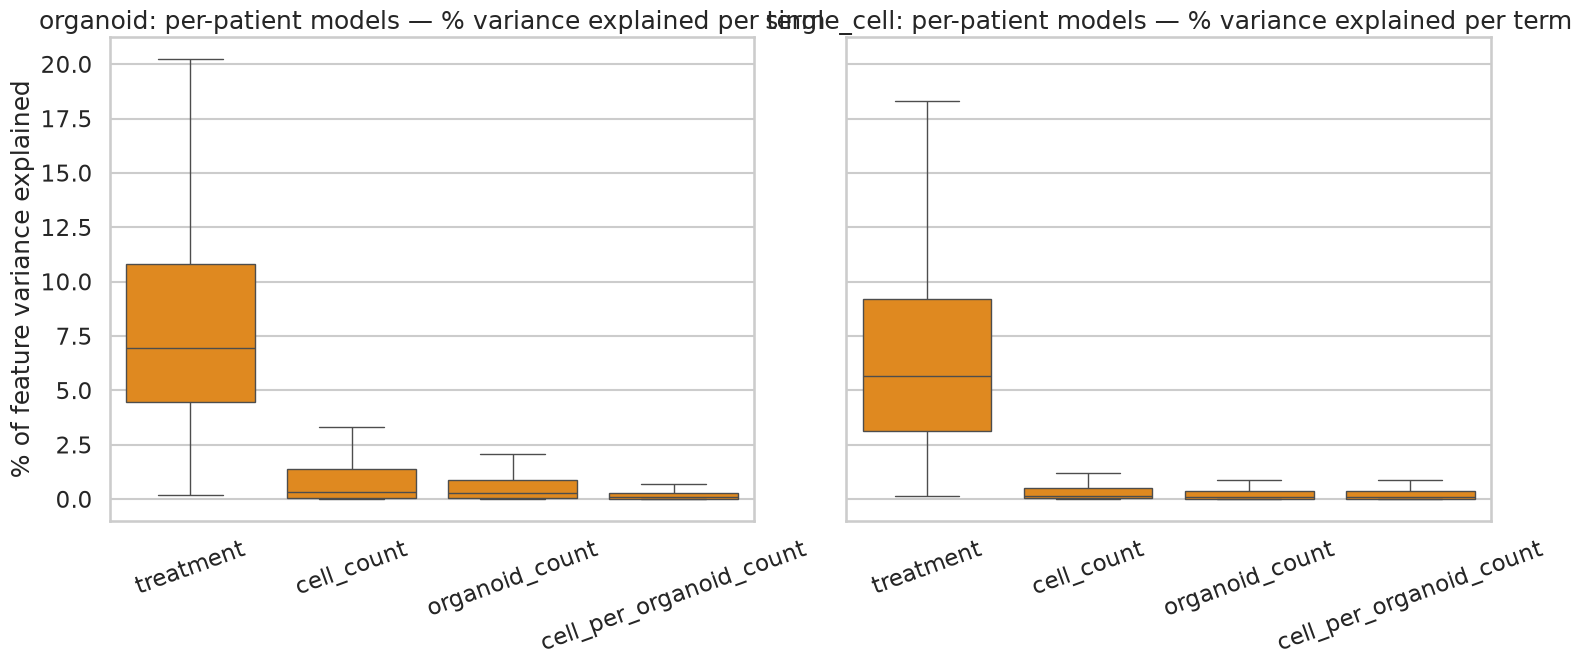

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (name, pdf) in zip(axes, anova_dfs.items()):
    plot_df = pdf[pdf["term"] != "residual"].copy()
    plot_df["term"] = pd.Categorical(
        plot_df["term"], categories=[t for t in TERM_ORDER if t != "residual"]
    )
    sns.boxplot(
        data=plot_df,
        x="term",
        y="pct_variance_explained",
        ax=ax,
        showfliers=False,
        color="darkorange",
    )
    ax.set_title(f"{name}: per-patient models — % variance explained per term")
    ax.set_xlabel("")
    ax.set_ylabel("% of feature variance explained")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(
    figures_path / "per_patient_term_importance_boxplot.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()